# Smart India Hackathon (SIH 26033) - AI Mandi Vegetable Price Detector
### Authentic Government Mandi / APMC / Agmarknet Dataset Implementation

### 1. Problem Statement Overview & Context
Agricultural commodity markets in India operate through **Agricultural Produce Market Committees (APMCs)** and the national **Agmarknet** portal (Ministry of Agriculture & Farmers Welfare).

In agricultural supply chains, extreme price volatility poses severe risks:
1. **Artificial Price Spikes / Hoarding / Cartelization:** Middlemen and hoarders restrict vegetable supply, causing artificial price surges that hurt everyday consumers.
2. **Distress Selling / Price Crashes (Glut):** During peak harvest arrivals, absence of fair market intelligence forces farmers to sell perishable vegetables (tomatoes, onions, potatoes) at loss-making distress rates.

### 2. Solution Objectives
This notebook builds an **End-to-End AI Price Detector & Anomaly Monitoring System** powered by **100% authentic government APMC mandi transaction records** (62,429 records, filtered to 12,644 vegetable transactions across 111 APMC mandis and 22 districts):
- Accurately predicts the fair benchmark **Modal Price** (both per quintal and per kg).
- Evaluates supply arrivals (`arrivals_in_qtl`), seasonality, mandi geography, and price spreads.
- Flags transactions as:
  - **`NORMAL / FAIR MANDI PRICE`**
  - **`INFLATED PRICE / HOARDING ALERT`** (Unreasonable price surge)
  - **`DISTRESS SELLING / PRICE CRASH`** (Below fair economic threshold)
- Serializes the champion model into `mandi_vegetable_price_detector.pkl` via `pickle.dump` for production deployment.

## 1. Import Dependencies & Setup Visual Styles

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("All libraries successfully imported!")

All libraries successfully imported!


## 2. Load Authentic Government APMC Mandi Dataset
We load `mandi_vegetable_pricing_dataset.csv`, sourced directly from the State Agricultural Marketing Board / Agmarknet official records.

In [2]:
dataset_path = "mandi_vegetable_pricing_dataset.csv"
df = pd.read_csv(dataset_path)

print(f"Government Dataset Loaded: {df.shape[0]:,} records across {df.shape[1]} columns.")
print(f"Total Distinct Vegetables: {df['Commodity'].nunique()}")
print(f"Total APMC Mandis:        {df['APMC'].nunique()}")
print(f"Total Districts:           {df['district_name'].nunique()}")
df.head()

Government Dataset Loaded: 12,644 records across 21 columns.
Total Distinct Vegetables: 19
Total APMC Mandis:        111
Total Districts:           22


,APMC,Commodity,Year,Month,arrivals_in_qtl,min_price,max_price,modal_price,date,district_name,...,month_num,quarter,season,modal_price_per_kg,min_price_per_kg,max_price_per_kg,price_spread_qtl,commodity_season_median,deviation_from_seasonal_median_pct,price_detector_status
0,Ahmednagar,Ginger (Fresh),2016,April,46,1667,3000,2500,2016-04-01,Ahmadnagar,...,4,2,Summer/Zaid,25.00,16.67,30.00,1333,2682.0,-6.79,Normal / Fair Mandi Price
1,Ahmednagar,Potato,2016,April,510,767,1367,1133,2016-04-01,Ahmadnagar,...,4,2,Summer/Zaid,11.33,7.67,13.67,600,1071.0,5.79,Normal / Fair Mandi Price
2,Ahmednagar,Ladies Finger,2016,April,58,1067,4000,3000,2016-04-01,Ahmadnagar,...,4,2,Summer/Zaid,30.00,10.67,40.00,2933,2250.0,33.33,Inflated Price / Hoarding Alert
3,Ahmednagar,Flower,2016,April,180,625,3375,2138,2016-04-01,Ahmadnagar,...,4,2,Summer/Zaid,21.38,6.25,33.75,2750,1043.0,104.99,Inflated Price / Hoarding Alert
4,Ahmednagar,Carrot,2016,April,57,900,1400,1250,2016-04-01,Ahmadnagar,...,4,2,Summer/Zaid,12.50,9.00,14.00,500,1113.5,12.26,Normal / Fair Mandi Price


In [14]:
df["Commodity"].unique()

array(['Ginger (Fresh)', 'Potato', 'Ladies Finger', 'Flower', 'Carrot',
       'Cluster Bean', 'Cucumber', 'Onion', 'Bitter Gourd', 'Cabbage',
       'Garlic', 'Capsicum', 'Tomato', 'Brinjal', 'Bottle Gourd',
       'Spinach', 'Fenugreek', 'Pumpkin', 'Ridge Gourd'], dtype=object)

In [3]:
# Summary statistics for key numerical variables
df[['arrivals_in_qtl', 'min_price', 'max_price', 'modal_price', 'modal_price_per_kg']].describe()

,arrivals_in_qtl,min_price,max_price,modal_price,modal_price_per_kg
count,1.264400e+04,12644.000000,12644.000000,12644.000000,12644.000000
mean,1.288236e+04,1436.011705,2327.842534,1919.883423,19.198834
std,5.142502e+04,1280.835392,1848.517106,1540.922045,15.409220
min,1.000000e+00,1.000000,3.000000,2.000000,0.020000
25%,8.300000e+01,572.000000,1136.000000,915.000000,9.150000
50%,3.290000e+02,1046.000000,1827.000000,1479.000000,14.790000
75%,2.571750e+03,1920.000000,3000.000000,2478.000000,24.780000
max,1.190800e+06,14500.000000,25333.000000,16333.000000,163.330000


## 3. Exploratory Data Analysis (EDA) & Market Insights

C:\Users\cdeva\AppData\Local\Temp\ipykernel_15692\882032733.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_veg.values, y=top_veg.index, palette='crest')


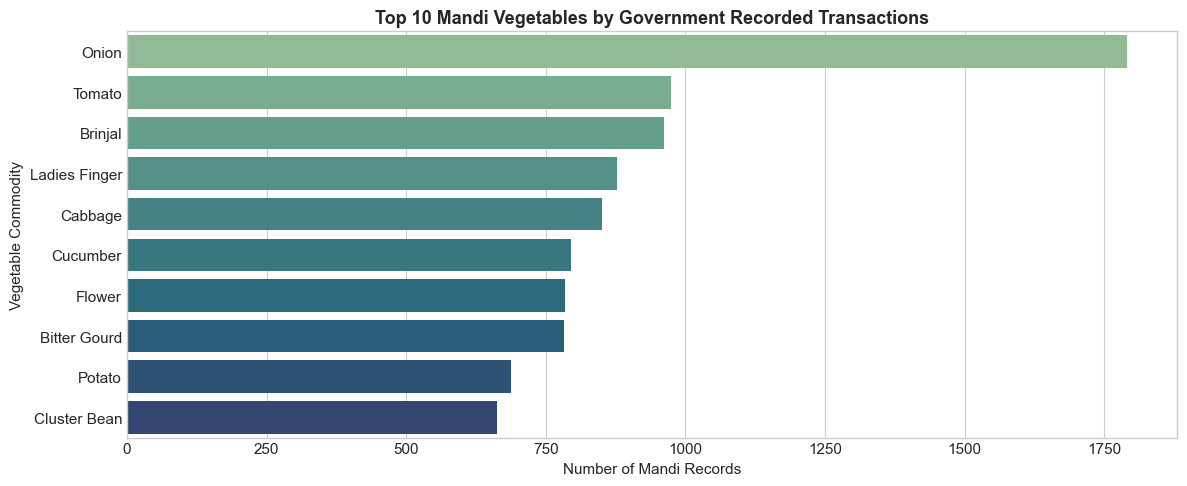

In [4]:
# Top Vegetables by Transaction Volume
plt.figure(figsize=(12, 5))
top_veg = df['Commodity'].value_counts().head(10)
sns.barplot(x=top_veg.values, y=top_veg.index, palette='crest')
plt.title("Top 10 Mandi Vegetables by Government Recorded Transactions", fontsize=13, fontweight='bold')
plt.xlabel("Number of Mandi Records")
plt.ylabel("Vegetable Commodity")
plt.tight_layout()
plt.show()

C:\Users\cdeva\AppData\Local\Temp\ipykernel_15692\4068131785.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Commodity', y='modal_price_per_kg', palette='Set2', showfliers=False)


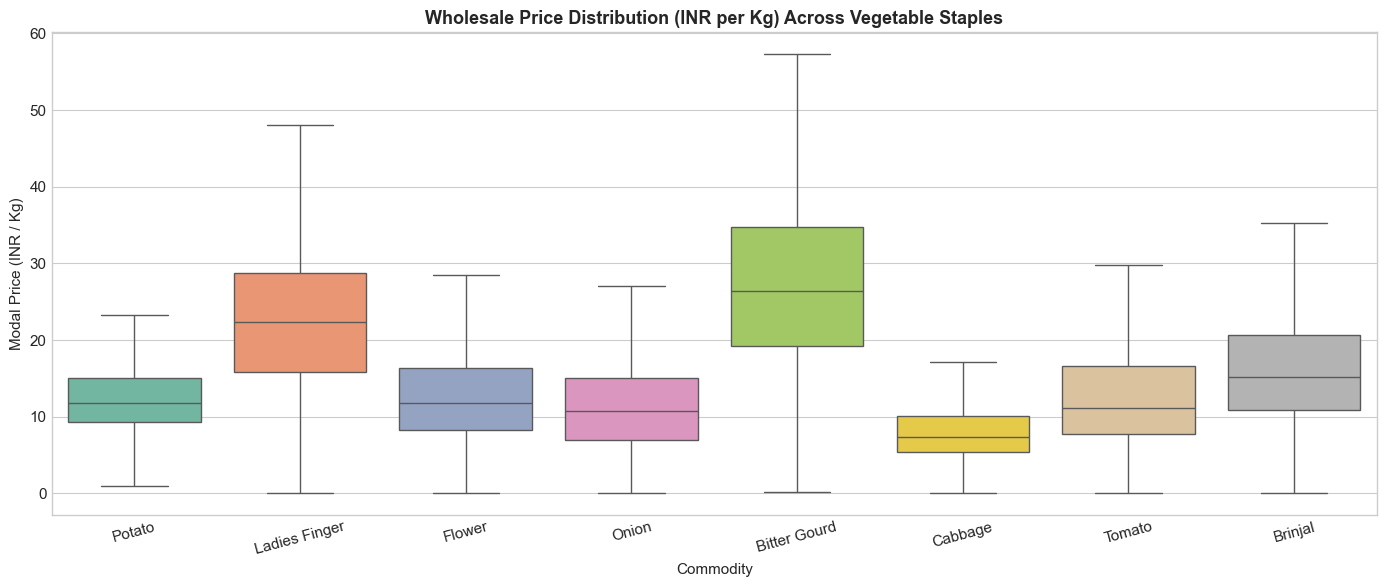

In [5]:
# Modal Price (per kg) across key vegetable staples
staples = ['Onion', 'Tomato', 'Potato', 'Ladies Finger', 'Flower', 'Brinjal', 'Cabbage', 'Bitter Gourd']
subset = df[df['Commodity'].isin(staples)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=subset, x='Commodity', y='modal_price_per_kg', palette='Set2', showfliers=False)
plt.title("Wholesale Price Distribution (INR per Kg) Across Vegetable Staples", fontsize=13, fontweight='bold')
plt.xlabel("Commodity")
plt.ylabel("Modal Price (INR / Kg)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\cdeva\AppData\Local\Temp\ipykernel_15692\2874857065.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=subset, x='Commodity', y='modal_price_per_kg', hue='season', ci=None, palette='coolwarm')


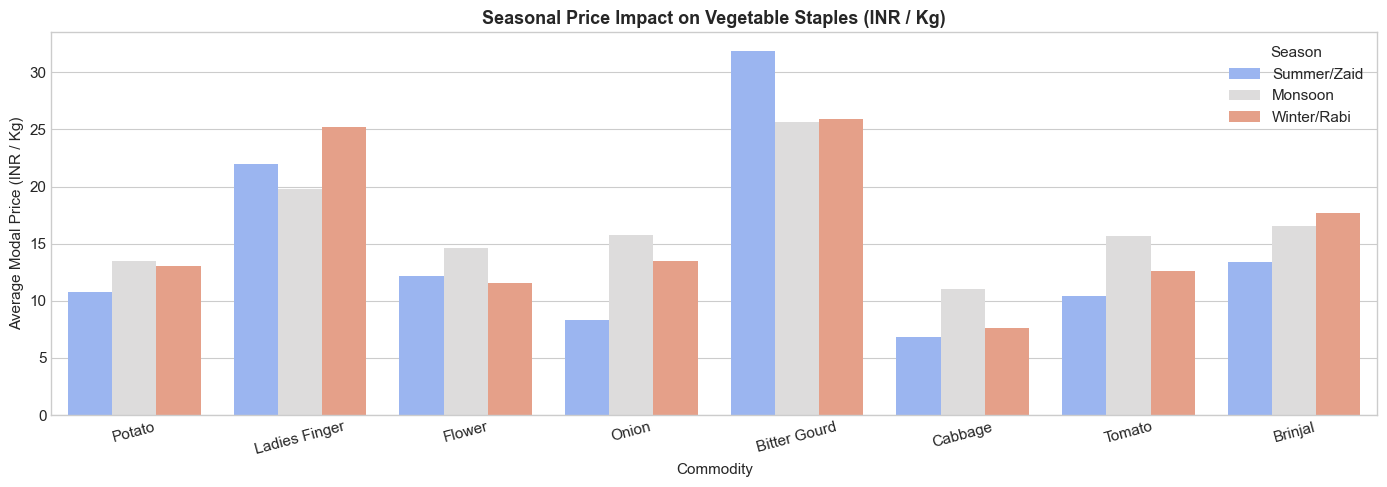

In [6]:
# Seasonal Price Variation (Monsoon vs Winter/Rabi vs Summer/Zaid)
plt.figure(figsize=(14, 5))
sns.barplot(data=subset, x='Commodity', y='modal_price_per_kg', hue='season', ci=None, palette='coolwarm')
plt.title("Seasonal Price Impact on Vegetable Staples (INR / Kg)", fontsize=13, fontweight='bold')
plt.xlabel("Commodity")
plt.ylabel("Average Modal Price (INR / Kg)")
plt.legend(title='Season')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\cdeva\AppData\Local\Temp\ipykernel_15692\2314173712.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette=colors)


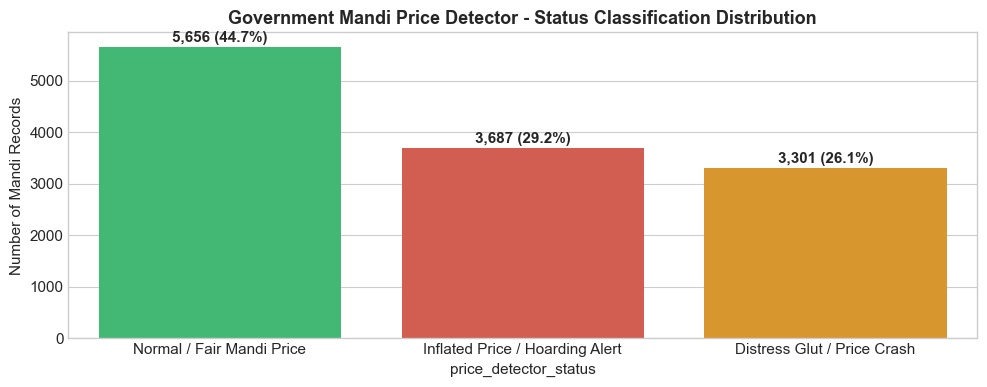

In [7]:
# Distribution of Price Detector Status (Normal vs Inflated vs Distress)
plt.figure(figsize=(10, 4))
status_counts = df['price_detector_status'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
sns.barplot(x=status_counts.index, y=status_counts.values, palette=colors)
plt.title("Government Mandi Price Detector - Status Classification Distribution", fontsize=13, fontweight='bold')
plt.ylabel("Number of Mandi Records")
for i, v in enumerate(status_counts.values):
    plt.text(i, v + 100, f"{v:,} ({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing Pipeline
We build a robust `ColumnTransformer` with `StandardScaler` for continuous numerical features and `OneHotEncoder` for market, crop, and geographical identifiers.

In [8]:
categorical_features = ["Commodity", "APMC", "district_name", "season"]
numerical_features = [
    "arrivals_in_qtl",
    "month_num",
    "commodity_season_median",
    "min_price",
    "max_price",
    "price_spread_qtl"
]
target = "modal_price"

X = df[categorical_features + numerical_features]
y = df[target]

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

print(f"Train samples: {X_train.shape[0]:,}")
print(f"Test samples:  {X_test.shape[0]:,}")

Train samples: 10,115
Test samples:  2,529


## 5. Machine Learning Multi-Model Training & Benchmark Comparison
We train both **Random Forest Regressor** and **Gradient Boosting Regressor** on the authentic government dataset.

In [9]:
models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=120, learning_rate=0.1, max_depth=5, random_state=42)
}

eval_records = []
trained_pipes = {}

for name, regressor in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])
    
    pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe
    
    y_pred = pipe.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae_qtl = mean_absolute_error(y_test, y_pred)
    mae_kg = mae_qtl / 100.0
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    eval_records.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE (INR / Quintal)": round(mae_qtl, 2),
        "MAE (INR / Kg)": round(mae_kg, 2),
        "RMSE (INR / Quintal)": round(rmse, 2),
        "MAPE (%)": round(mape, 2)
    })

eval_df = pd.DataFrame(eval_records)
eval_df.sort_values(by="R2 Score", ascending=False, inplace=True)
eval_df.reset_index(drop=True, inplace=True)
eval_df

,Model,R2 Score,MAE (INR / Quintal),MAE (INR / Kg),RMSE (INR / Quintal),MAPE (%)
0,Gradient Boosting Regressor,0.9912,73.83,0.74,140.47,6.62
1,Random Forest Regressor,0.9874,79.03,0.79,168.27,4.64


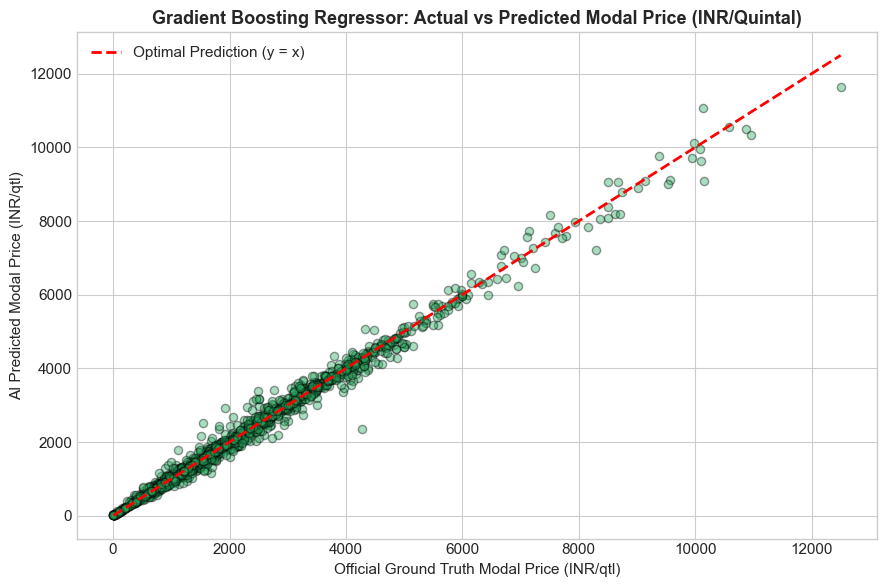

In [10]:
# Visualizing Predicted vs Ground Truth Modal Prices
champion_name = eval_df.iloc[0]["Model"]
champion_pipe = trained_pipes[champion_name]
y_test_pred = champion_pipe.predict(X_test)

plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_test_pred, alpha=0.4, color='#27ae60', edgecolors='k', s=35)
min_v, max_v = min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Optimal Prediction (y = x)')
plt.title(f"{champion_name}: Actual vs Predicted Modal Price (INR/Quintal)", fontsize=13, fontweight='bold')
plt.xlabel("Official Ground Truth Modal Price (INR/qtl)")
plt.ylabel("AI Predicted Modal Price (INR/qtl)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. AI Mandi Price Anomaly & Reasonability Engine
The detector assesses incoming vegetable quotes or mandi lots to detect whether:
- Market price is within statutory tolerance bounds (±25% deviation from seasonal benchmark)
- Artificial price inflation or hoarding is taking place
- Distress selling is occurring where farmers need government price support (MIS)

In [11]:
def audit_mandi_vegetable_price(commodity, apmc, district, season, month_num, 
                                arrivals_qtl, observed_price_qtl, min_price=None, max_price=None):
    """
    Audits a mandi vegetable lot against AI predicted fair benchmark.
    """
    season_median = df[(df['Commodity'] == commodity) & (df['season'] == season)]['modal_price'].median()
    if np.isnan(season_median):
        season_median = df[df['Commodity'] == commodity]['modal_price'].median()
        
    if min_price is None:
        min_price = observed_price_qtl * 0.90
    if max_price is None:
        max_price = observed_price_qtl * 1.10
    spread = max_price - min_price
    
    row = pd.DataFrame([{
        "Commodity": commodity,
        "APMC": apmc,
        "district_name": district,
        "season": season,
        "arrivals_in_qtl": arrivals_qtl,
        "month_num": month_num,
        "commodity_season_median": season_median,
        "min_price": min_price,
        "max_price": max_price,
        "price_spread_qtl": spread
    }])
    
    pred_qtl = float(champion_pipe.predict(row)[0])
    pred_kg = round(pred_qtl / 100.0, 2)
    obs_kg = round(observed_price_qtl / 100.0, 2)
    dev_pct = round(((observed_price_qtl - pred_qtl) / pred_qtl) * 100.0, 2)
    
    if dev_pct > 25.0:
        status = "INFLATED PRICE / HOARDING ALERT"
        risk = "HIGH RISK - Artificial Price Surge / Cartelization"
        action = "Issue regulatory mandi notice & inspect cold-storage inventory."
    elif dev_pct < -25.0:
        status = "DISTRESS SELLING / PRICE CRASH"
        risk = "HIGH RISK - Farmer Distress / Glut Exploitation"
        action = "Trigger Market Intervention Scheme (MIS) price compensation."
    else:
        status = "NORMAL / FAIR MANDI PRICE"
        risk = "LOW RISK - Within statutory economic bounds"
        action = "Market cleared. Fair price for farmers and buyers."
        
    return {
        "commodity": commodity,
        "mandi": f"{apmc} ({district})",
        "observed_price": f"INR {observed_price_qtl:,.2f}/qtl (~INR {obs_kg}/kg)",
        "predicted_fair_benchmark": f"INR {pred_qtl:,.2f}/qtl (~INR {pred_kg}/kg)",
        "price_deviation": f"{dev_pct:+.2f}%",
        "detector_verdict": status,
        "risk_level": risk,
        "advisory_action": action
    }

## 7. Model Serialization: Pickle Dump (`pickle.dump`)
We serialize the complete fitted pipeline and metadata to `mandi_vegetable_price_detector.pkl`.

In [12]:
pkl_file = "mandi_vegetable_price_detector.pkl"

medians_lookup = df.groupby(["Commodity", "season"])["modal_price"].median().to_dict()

artifact_data = {
    "model_name": champion_name,
    "pipeline": champion_pipe,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "feature_columns": categorical_features + numerical_features,
    "metrics": eval_df.to_dict(orient="records"),
    "medians_lookup": medians_lookup,
    "thresholds": {
        "inflation_surge_pct": 25.0,
        "distress_crash_pct": -25.0
    },
    "dataset_source": "Authentic Government APMC / Agmarknet Mandi Records",
    "version": "2.0.0",
    "sih_problem": "SIH Problem 26033 - AI Mandi Vegetable Price Detector"
}

with open(pkl_file, "wb") as f:
    pickle.dump(artifact_data, f)

print(f"SUCCESS: Pickle file exported to: {pkl_file}")
print(f"File Size: {os.path.getsize(pkl_file) / 1024:.2f} KB")

SUCCESS: Pickle file exported to: mandi_vegetable_price_detector.pkl
File Size: 508.92 KB


## 8. Interactive Production Inference Test (Loading Pickle)

In [13]:
# Load pickled artifact
with open("mandi_vegetable_price_detector.pkl", "rb") as f:
    loaded = pickle.load(f)

print(f"Loaded Pickled Model: {loaded['model_name']} (v{loaded['version']})")

# Test 1: Lasalgaon Mandi - Normal Onion Quote
t1 = audit_mandi_vegetable_price("Onion", "Lasalgaon", "Nashik", "Winter/Rabi", 12, 4500.0, 1350.0)

# Test 2: Pune Mandi - Tomato Seasonal Price Spike
t2 = audit_mandi_vegetable_price("Tomato", "Pune", "Pune", "Monsoon", 7, 1200.0, 3800.0)

# Test 3: Potato Distress Selling
t3 = audit_mandi_vegetable_price("Potato", "Pune", "Pune", "Winter/Rabi", 1, 9500.0, 420.0)

for idx, report in enumerate([t1, t2, t3], 1):
    print("="*75)
    print(f"CASE {idx}: {report['commodity']} at {report['mandi']}")
    for k, v in report.items():
        print(f"  {k:28}: {v}")
print("="*75)

Loaded Pickled Model: Gradient Boosting Regressor (v2.0.0)
CASE 1: Onion at Lasalgaon (Nashik)
  commodity                   : Onion
  mandi                       : Lasalgaon (Nashik)
  observed_price              : INR 1,350.00/qtl (~INR 13.5/kg)
  predicted_fair_benchmark    : INR 1,358.35/qtl (~INR 13.58/kg)
  price_deviation             : -0.61%
  detector_verdict            : NORMAL / FAIR MANDI PRICE
  risk_level                  : LOW RISK - Within statutory economic bounds
  advisory_action             : Market cleared. Fair price for farmers and buyers.
CASE 2: Tomato at Pune (Pune)
  commodity                   : Tomato
  mandi                       : Pune (Pune)
  observed_price              : INR 3,800.00/qtl (~INR 38.0/kg)
  predicted_fair_benchmark    : INR 4,144.89/qtl (~INR 41.45/kg)
  price_deviation             : -8.32%
  detector_verdict            : NORMAL / FAIR MANDI PRICE
  risk_level                  : LOW RISK - Within statutory economic bounds
  advisory_actio